In [9]:
%matplotlib widget

In [10]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os

In [11]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_553/FORS2.2021-08-21T06_02_18.000/Mrk-553_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_553/FORS2.2021-08-21T06_02_18.000/Mrk-553_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     361   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        42   (2094, 964)   float32   


In [12]:
image_cut = image[75:175, 0:1890]
image_error_cut = image_error[75:175, 0:1890]

In [13]:
wv = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wv, y)
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelenght')

Text(0.5, 50.74305555555554, 'wavelenght')

In [14]:
z = 0.01505 
l_HA_z = 6563 * (1+z)
l_HB_z = 4861 * (1+z) 
l_NII_z = 6583 * (1+z)
l_SII_z = 6717 * (1+z)
l_OIII_z = 5007 * (1+z)

l_HA = 6654
l_HB = 4929
l_NII_2 = 6676
l_NII_1 = 6641
l_SII_1 = 6811
l_SII_2 = 6825
l_OIII_1 = 5029
l_OIII_2 = 5077

Text(0.5, 1.0, 'H$\\alpha$')

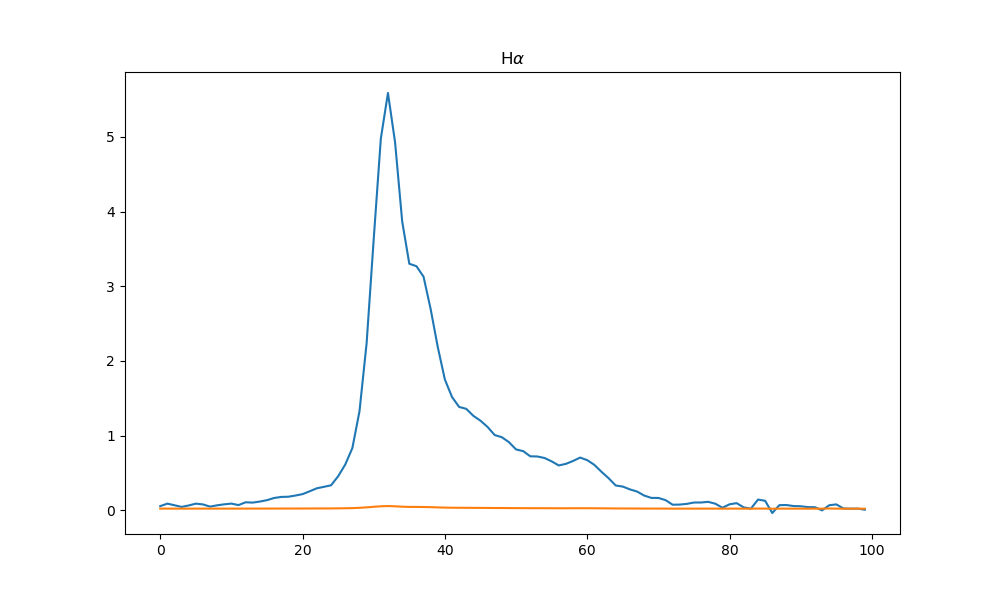

In [15]:
mask_HA = (wv > l_HA-8)*(wv < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')
#fit_HA = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Fit_code/Halpha_fit.csv", index_col=0)

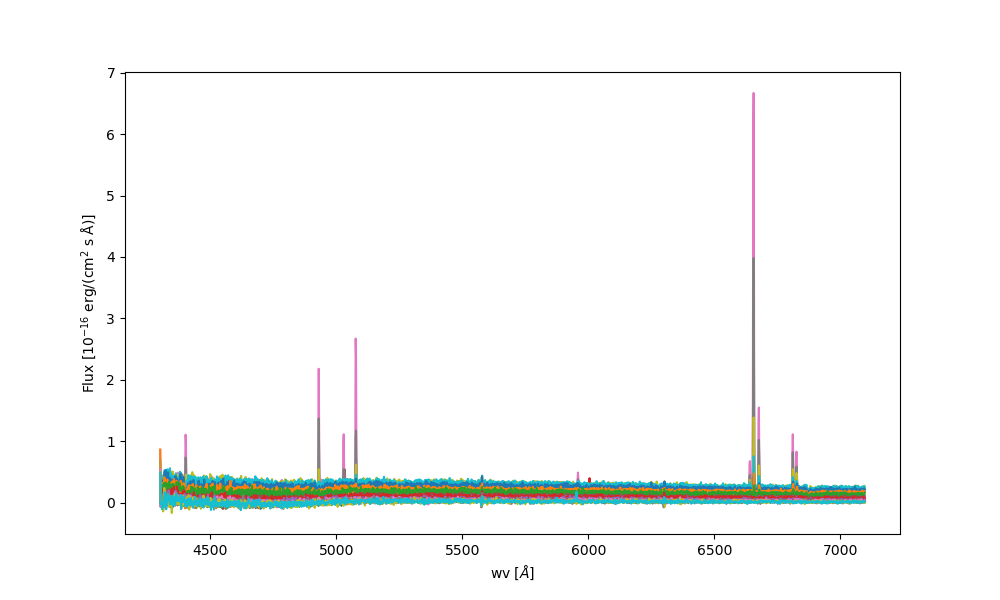

In [16]:
def extraction(x_axes, x_min, x_max, image_cut, image_error_cut):
    mask = (x_axes > x_min)*(x_axes < x_max)
    spectrum = np.sum(image_cut[mask, :], axis = 0)
    spectrum_err = np.sqrt(np.sum(image_error_cut[mask, :]**2, axis = 0))
    return spectrum, spectrum_err

os.makedirs('20ext', exist_ok=True)

spectra =  np.zeros((20, image_cut.shape[1]))
spectra_err = np.zeros((20, image_error_cut.shape[1]))
plt.figure(figsize=(10, 6))
for i in range(20):
    x_min = i * 5
    x_max = x_min + 5
    spectra[i], spectra_err[i] = extraction(x_axes, x_min, x_max, image_cut, image_error_cut)

    plt.plot(wv, spectra[i], label = f'spectrum {i+1}')
    plt.xlabel(r'wv [$\AA$]')
    plt.ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]')
    
    spectrum_table = np.concatenate((wv.reshape(-1, 1), 
                                    spectra[i].reshape(-1, 1), spectra_err[i].reshape(-1, 1)), axis=1)
    filename = os.path.join('20ext', f'Spectrum_{i+1}.txt')  # Salva come spectrum_1.txt ... spectrum_20.txt
    np.savetxt(filename, spectrum_table)

## S/N continuum

In [17]:
mask_continuum_1 = (wv > 4500)*(wv < 4800)
mask_continuum_2 = (wv > 5300)*(wv < 5800)
mask_continuum_3 = (wv > 6000)*(wv < 6500)
# Liste per contenere i risultati
SNR = []
Signal = []
Noise = []
# Calcolo per ogni spettro
for i in range(20):  # Assumendo che peaks definisca il numero di spettri
    snr = []
    signal = []
    noise = []
    
    # Calcolo per continuum_1
    sig_1 = np.mean(spectra[i, mask_continuum_1])
    noise_1 = np.std(spectra[i, mask_continuum_1])
    snr_1 = sig_1 / noise_1
    
    # Calcolo per continuum_2  
    sig_2 = np.mean(spectra[i, mask_continuum_2])
    noise_2 = np.std(spectra[i, mask_continuum_2])
    snr_2 = sig_2 / noise_2
    
    # Calcolo per continuum_3
    sig_3 = np.mean(spectra[i, mask_continuum_3])
    noise_3 = np.std(spectra[i, mask_continuum_3])
    snr_3 = sig_3 / noise_3
    
    # Aggiunta ai risultati
    snr.extend([snr_1, snr_2, snr_3])
    signal.extend([sig_1, sig_2, sig_3])
    noise.extend([noise_1, noise_2, noise_3])
    
    SNR.append(snr)
    Signal.append(signal)
    Noise.append(noise)
    
# Conversione in array numpy e trasposizione
SNR_array = np.array(SNR).T  # Trasponi per avere continuum come righe
Signal_array = np.array(Signal).T
Noise_array = np.array(Noise).T

# Creazione del DataFrame
# Nomi delle colonne per ogni spettro
col_names = [f'Spectrum_{i+1}' for i in range(20)]
# Creazione di DataFrames separati per ogni metrica
df_snr = pd.DataFrame(SNR_array, 
                      columns=col_names,
                      index=['Continuum_1', 'Continuum_2', 'Continuum_3'])
df_signal = pd.DataFrame(Signal_array, 
                         columns=col_names,
                         index=['Continuum_1', 'Continuum_2', 'Continuum_3'])
df_noise = pd.DataFrame(Noise_array, 
                        columns=col_names,
                        index=['Continuum_1', 'Continuum_2', 'Continuum_3'])
# Combinazione in un unico DataFrame con MultiIndex per le colonne
df_combined = pd.concat([df_snr, df_signal, df_noise], 
                        keys=['SNR', 'Signal', 'Noise'], 
                        axis=1)
print("DataFrame SNR:")
print(df_snr)
print("\nDataFrame Signal:")
print(df_signal)
print("\nDataFrame Noise:")
print(df_noise)
print("\nDataFrame Combinato:")
print(df_combined)
# Salvataggio dei file
os.path.join('20ext', 'SNR_20ext_continuum.csv')
df_path_snr = os.path.join('20ext', 'SNR_20ext_continuum.csv')
df_path_signal = os.path.join('20ext', 'Signal_20ext_continuum.csv')
df_path_noise = os.path.join('20ext', 'Noise_20ext_continuum.csv')
df_path_combined = os.path.join('20ext', 'Combined_20ext_continuum.csv')
# Assicurati che la directory esista
os.makedirs('20ext', exist_ok=True)
df_snr.to_csv(df_path_snr, float_format='%.3f')
df_signal.to_csv(df_path_signal, float_format='%.3f')
df_noise.to_csv(df_path_noise, float_format='%.3f')
df_combined.to_csv(df_path_combined, float_format='%.3f')
print(f"\nFile salvati in:")
print(f"- {df_path_snr}")
print(f"- {df_path_signal}")
print(f"- {df_path_noise}")
print(f"- {df_path_combined}")

DataFrame SNR:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4  Spectrum_5  \
Continuum_1   -0.351209   -0.395273    0.083629    1.060284    2.146072   
Continuum_2    1.791875    1.960221    2.598609    3.891042    5.742543   
Continuum_3    1.632278    1.990586    2.614913    2.661658    5.857027   

             Spectrum_6  Spectrum_7  Spectrum_8  Spectrum_9  Spectrum_10  \
Continuum_1    3.165599    6.688015    7.054736    8.087093     8.239455   
Continuum_2    7.028505   10.877114   10.683734   13.354892    12.711970   
Continuum_3    7.088043   11.464190   11.045638   13.071471    13.370100   

             Spectrum_11  Spectrum_12  Spectrum_13  Spectrum_14  Spectrum_15  \
Continuum_1     7.174438     5.660369     4.611576     1.664150     0.408539   
Continuum_2    11.527294    10.273966     8.383361     5.076861     3.028207   
Continuum_3    11.484222     9.841938     8.705569     5.200111     2.867645   

             Spectrum_16  Spectrum_17  Spectrum_18  Spectr

## Redshift

In [18]:
from astropy.modeling import models
import astropy.units as u
from specutils import Spectrum
import astropy.units as u
from specutils.fitting import find_lines_threshold, fit_generic_continuum
from specutils.manipulation import noise_region_uncertainty
from astropy.nddata import StdDevUncertainty
from astropy.modeling.fitting import LinearLSQFitter

Numero di righe trovate (regione centrale): 10
   line_center     line_type  line_center_index
     Angstrom                                  
------------------ ---------- -----------------
  4367.33999999998   emission                27
 5156.179999999747   emission               560
 5577.979999999623   emission               845
 4698.859999999882 absorption               251
 4895.699999999824 absorption               384
 5575.019999999624 absorption               843
 6106.339999999467 absorption              1202
  6232.13999999943 absorption              1287
6254.3399999994235 absorption              1302
 6547.379999999337 absorption              1500
Numero di righe trovate (regione centrale): 8
   line_center    line_type  line_center_index
     Angstrom                                 
----------------- ---------- -----------------
5031.859999999784   emission               476
5577.979999999623   emission               845
6864.099999999244   emission              1714
4

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_14148\3592871693.py:45: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  f3, ax3 = plt.subplots(figsize=(10,8))

If you want to suppress this warning either type 'specutils.conf.do_continuum_function_check = False' or see http://docs.astropy.org/en/stable/config/#adding-new-configuration-items for other ways to configure the warning. [specutils.analysis.flux]


Numero di righe trovate (regione centrale): 13
   line_center     line_type  line_center_index
     Angstrom                                  
------------------ ---------- -----------------
 5165.059999999745   emission               566
 5185.779999999739   emission               580
 5577.979999999623   emission               845
 5875.459999999535   emission              1046
 5952.419999999513   emission              1098
  4502.01999999994 absorption               118
 4513.859999999937 absorption               126
4620.4199999999055 absorption               198
 4737.339999999871 absorption               277
 4781.739999999858 absorption               307
 4805.419999999851 absorption               323
 4861.659999999834 absorption               361
 6630.259999999313 absorption              1556


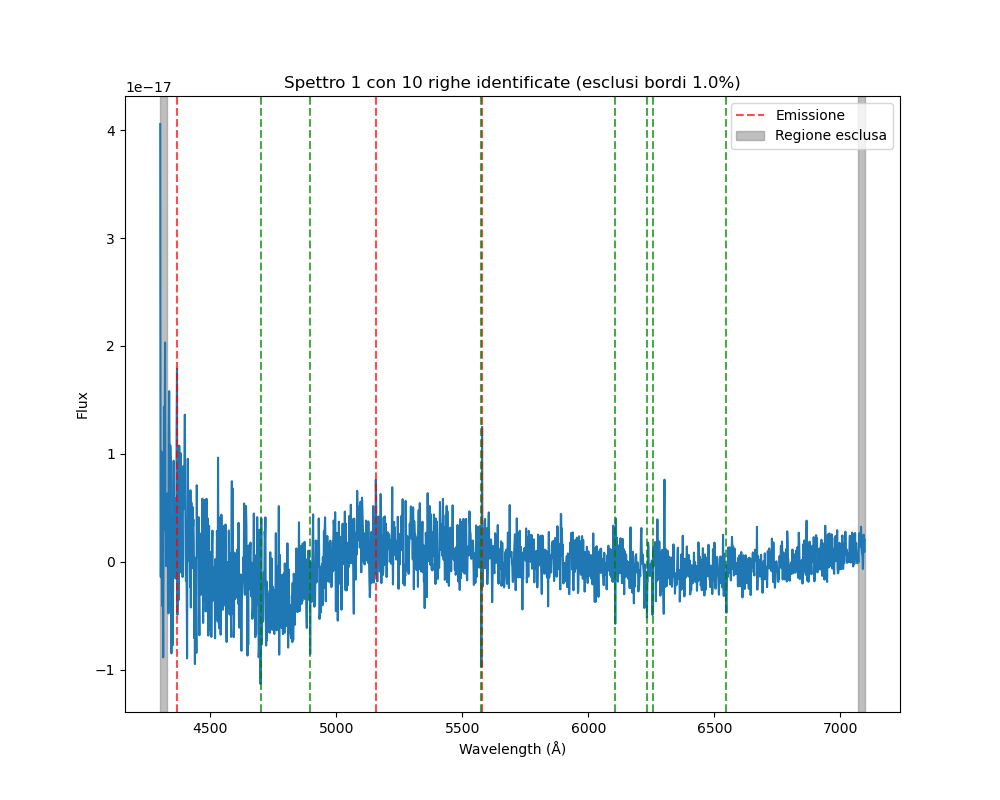

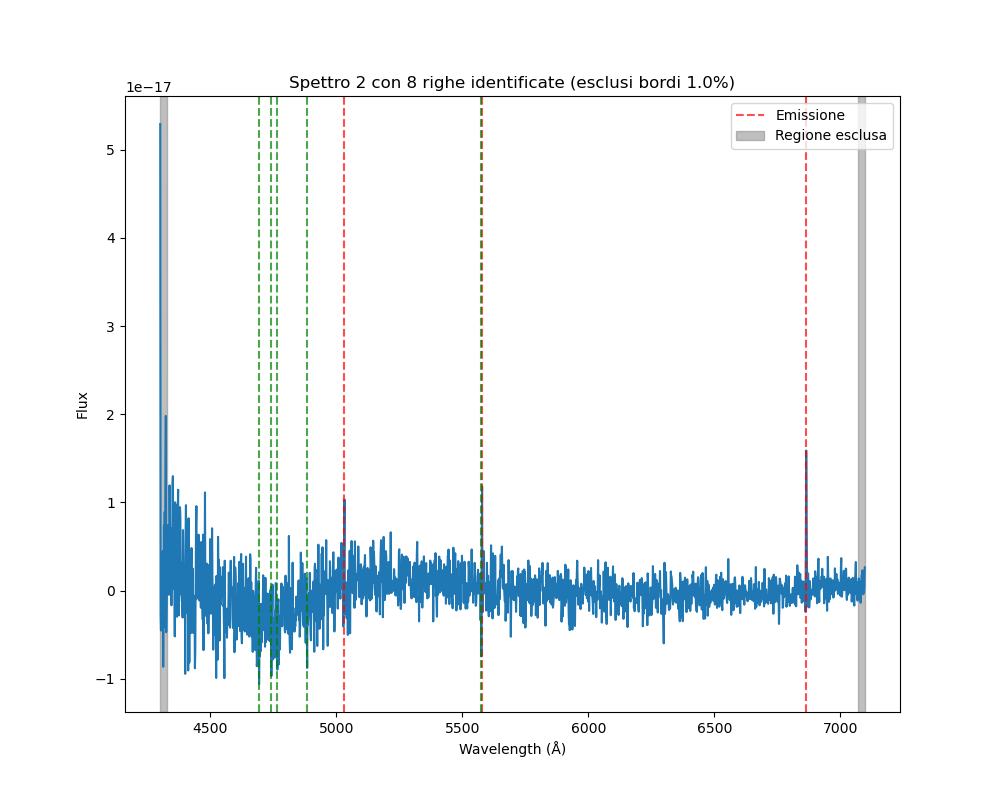

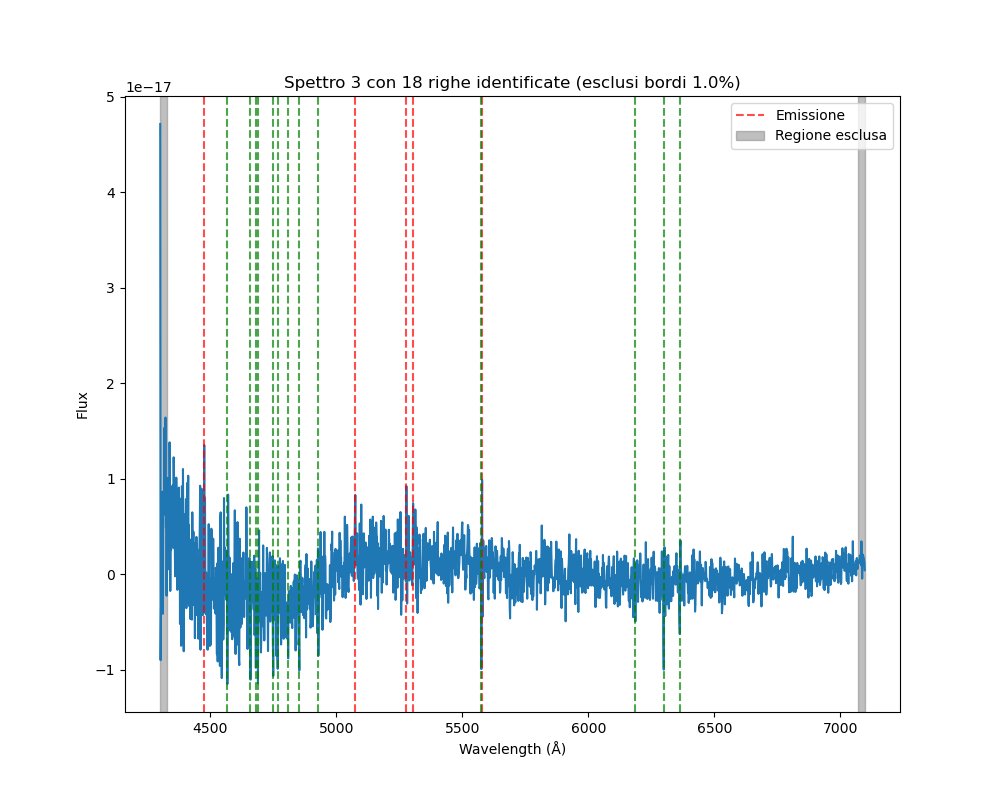

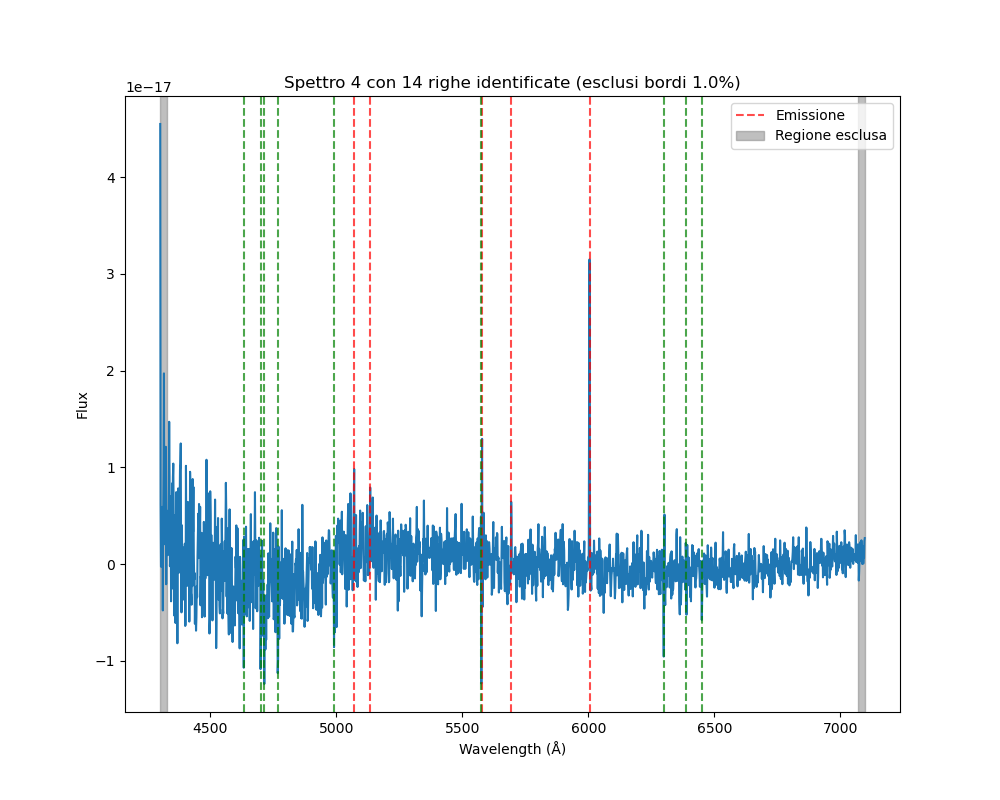

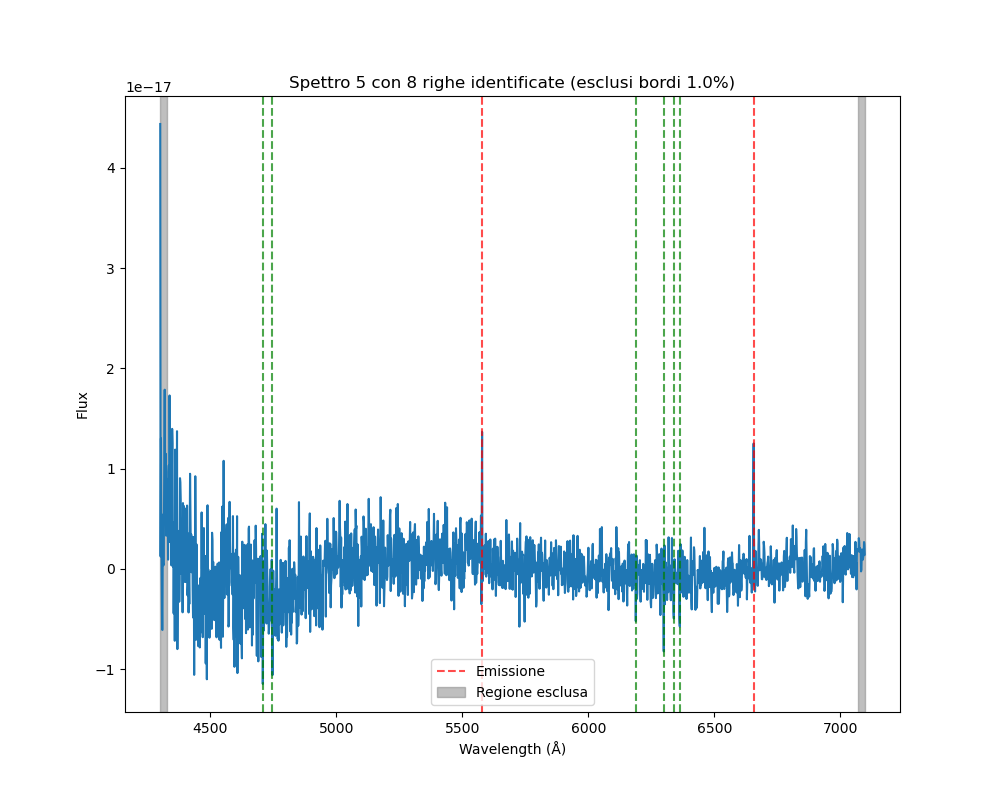

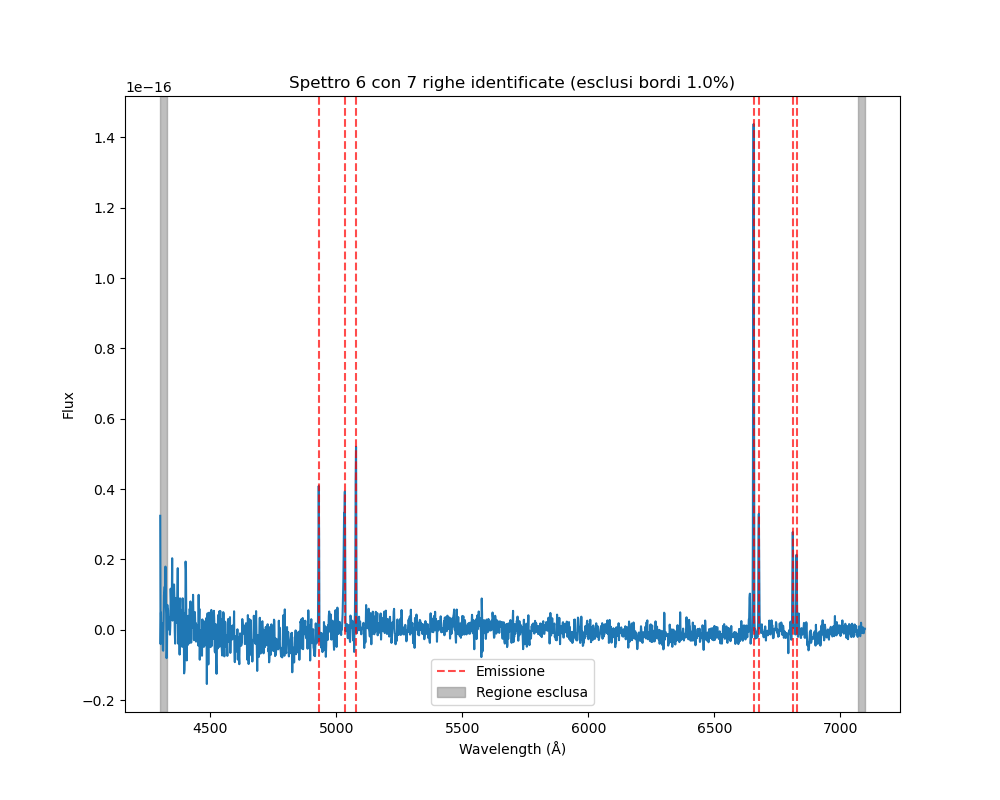

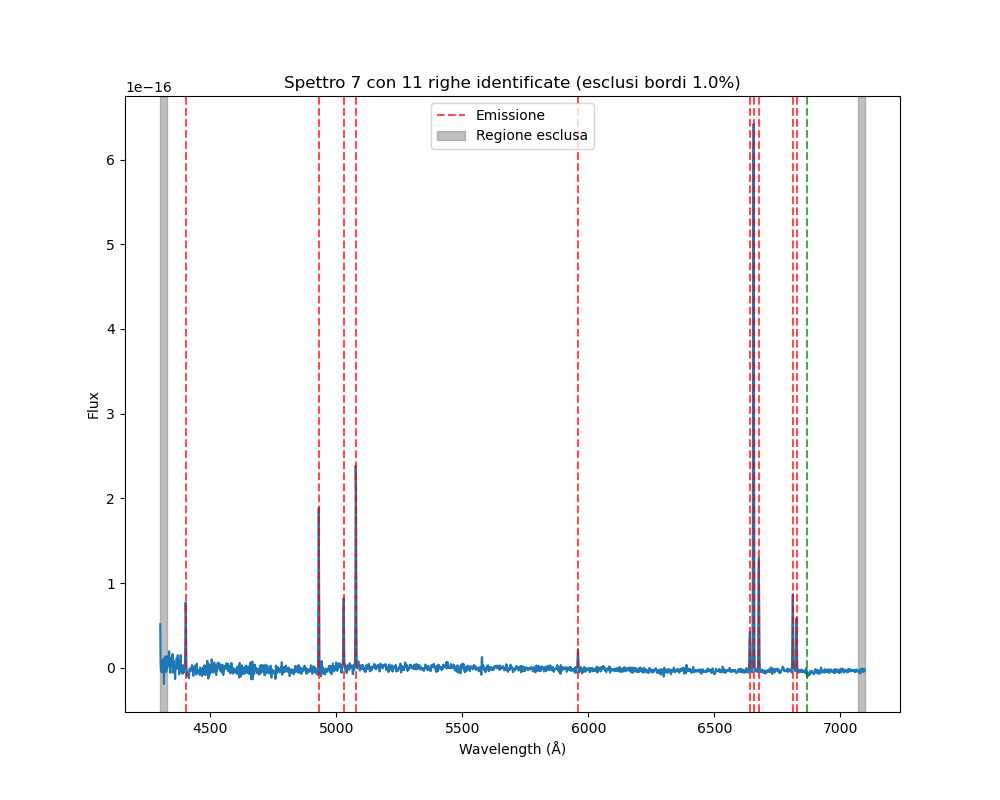

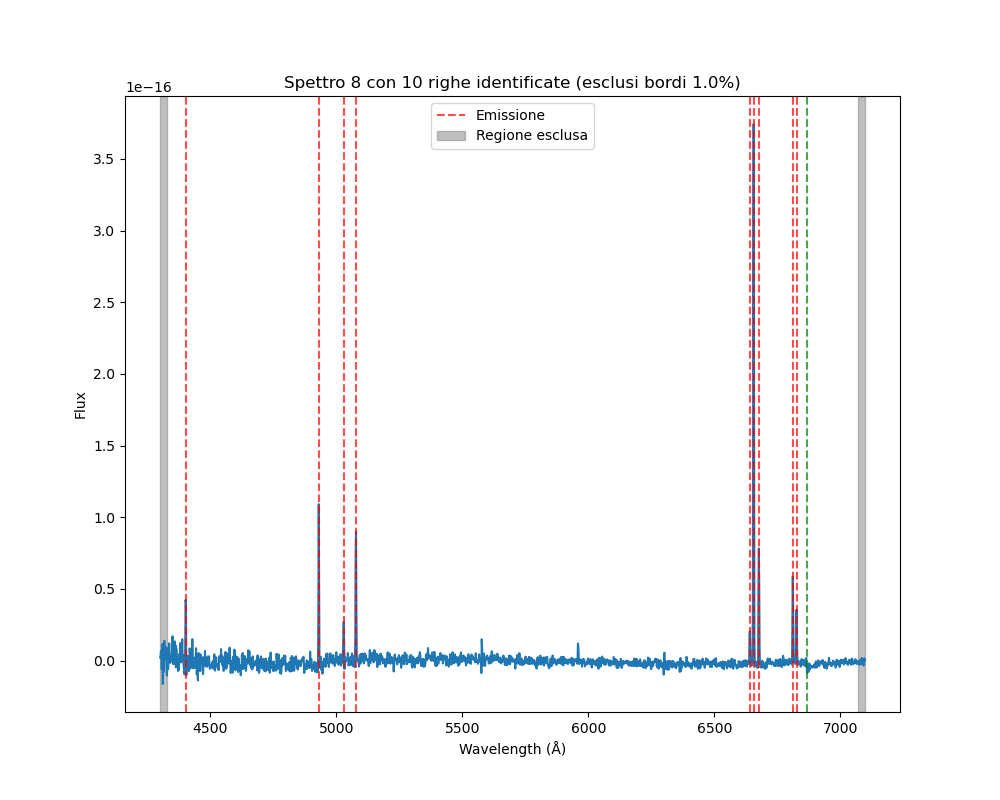

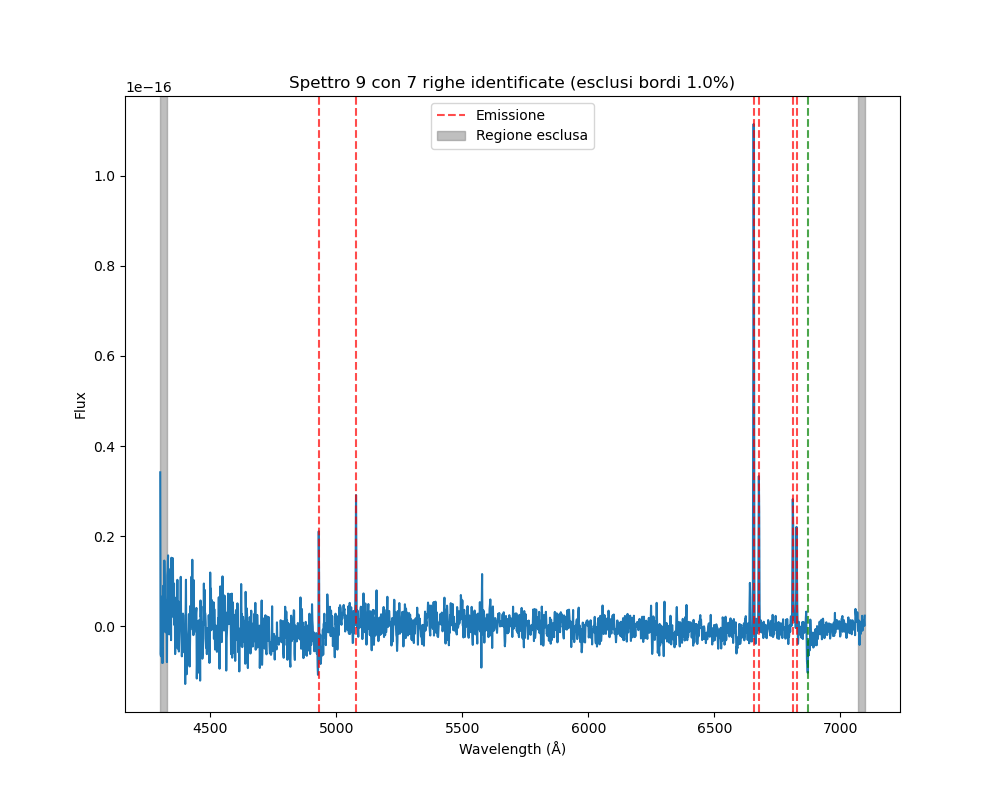

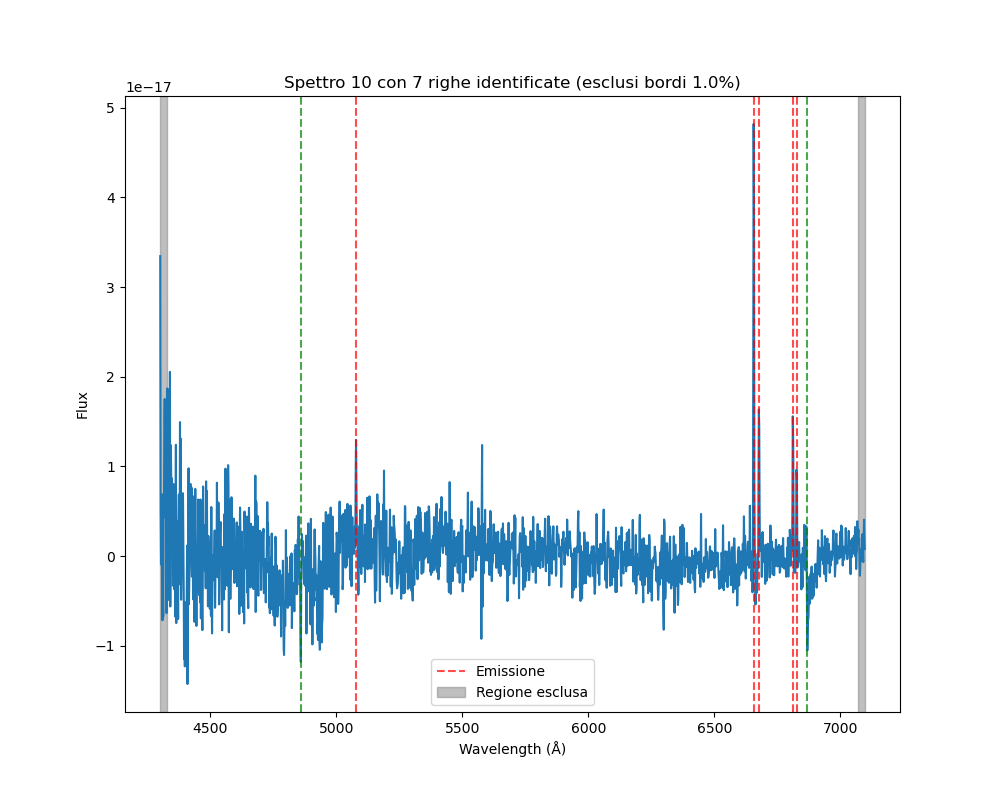

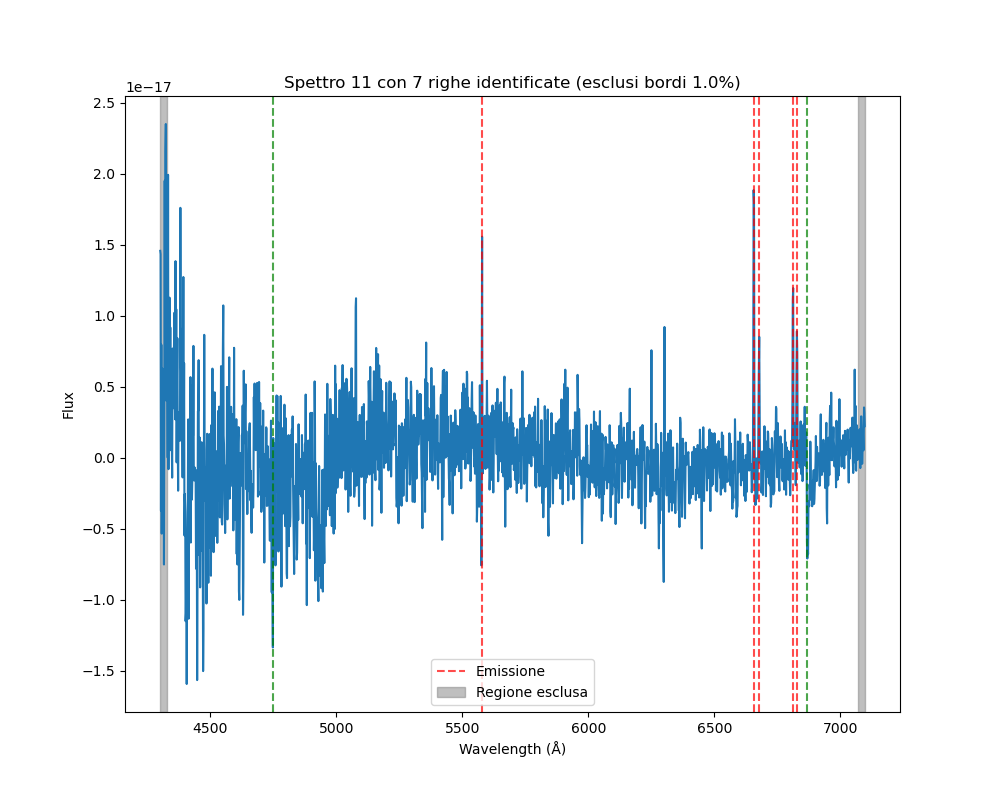

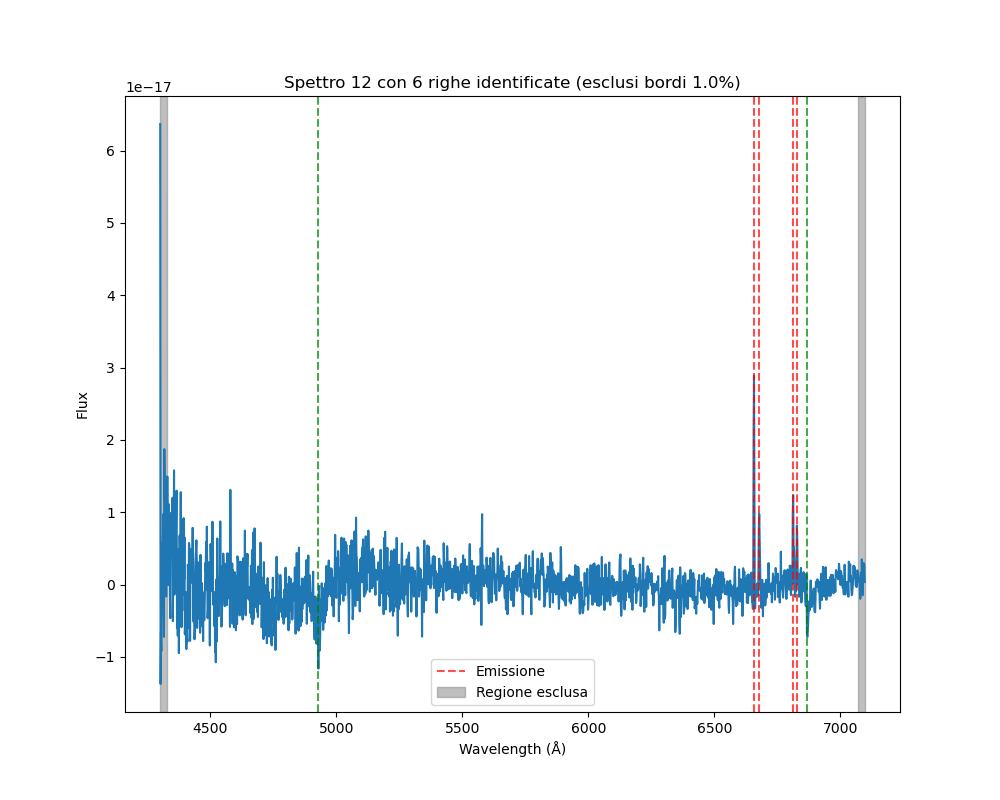

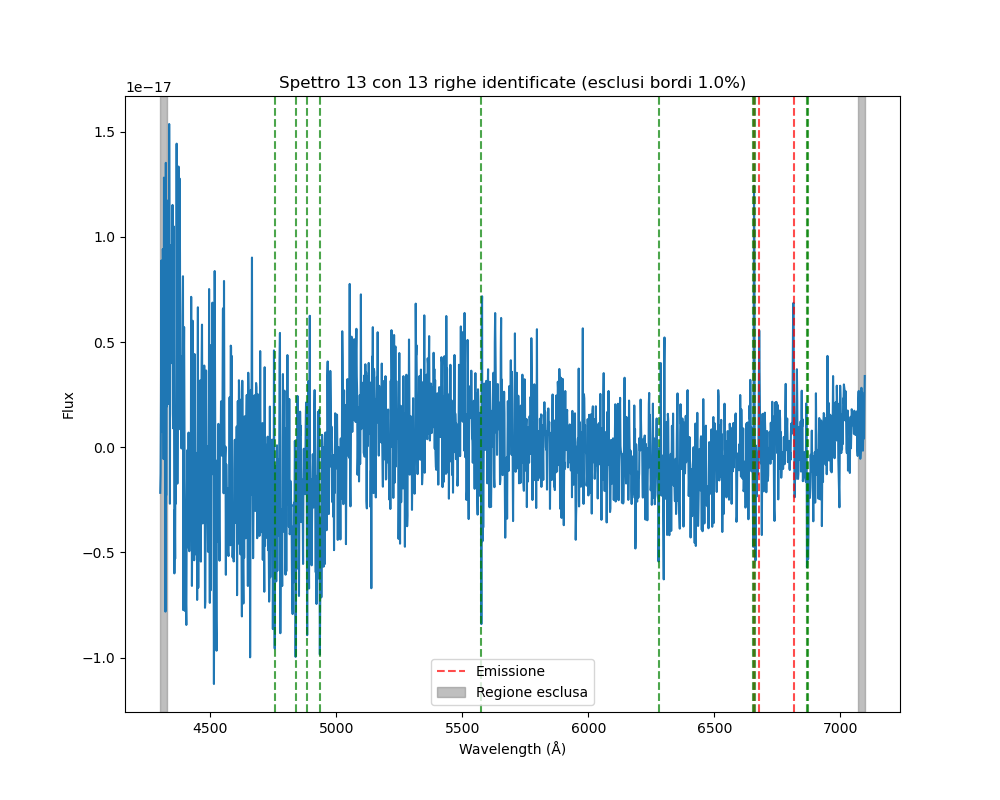

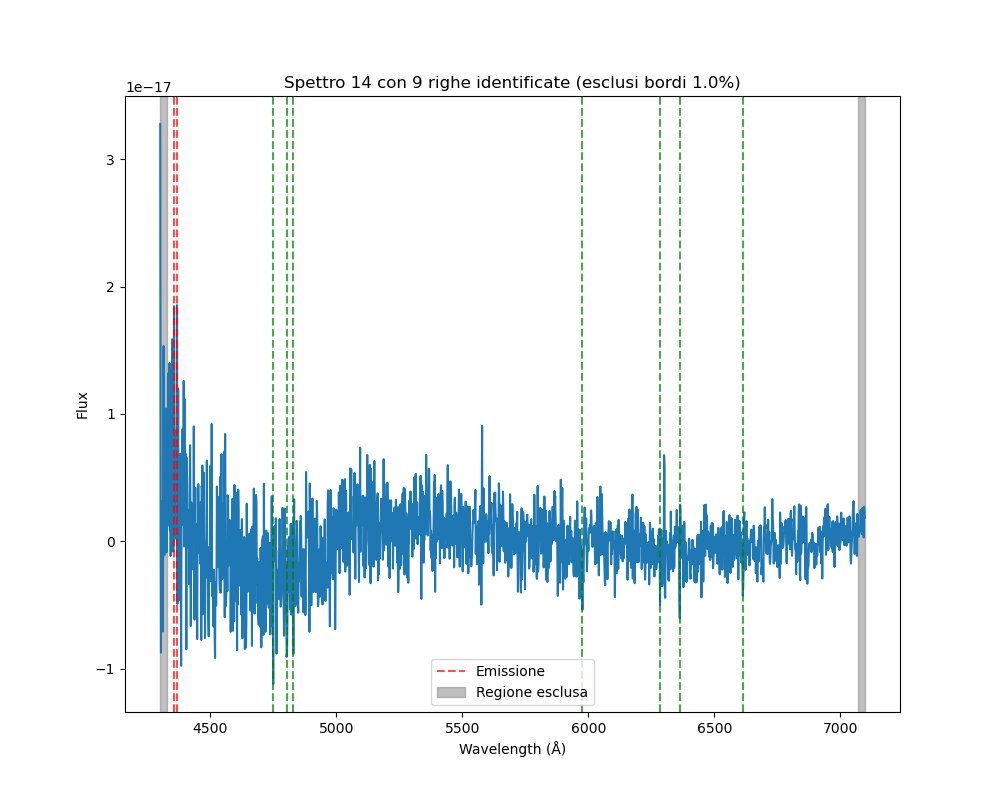

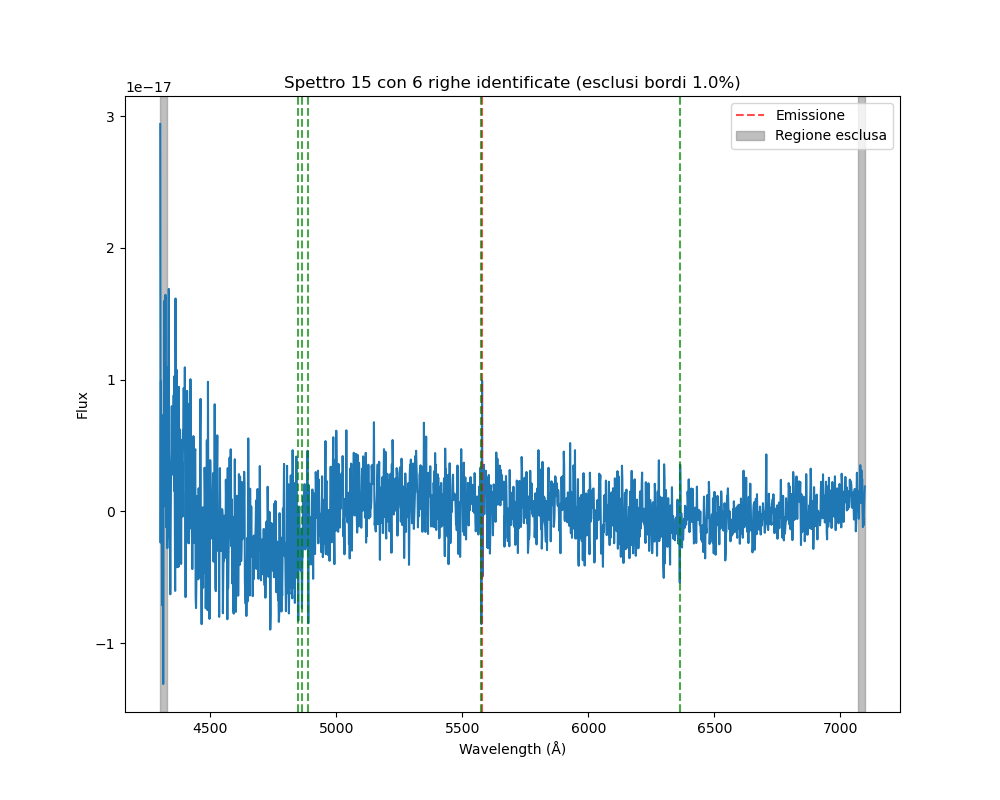

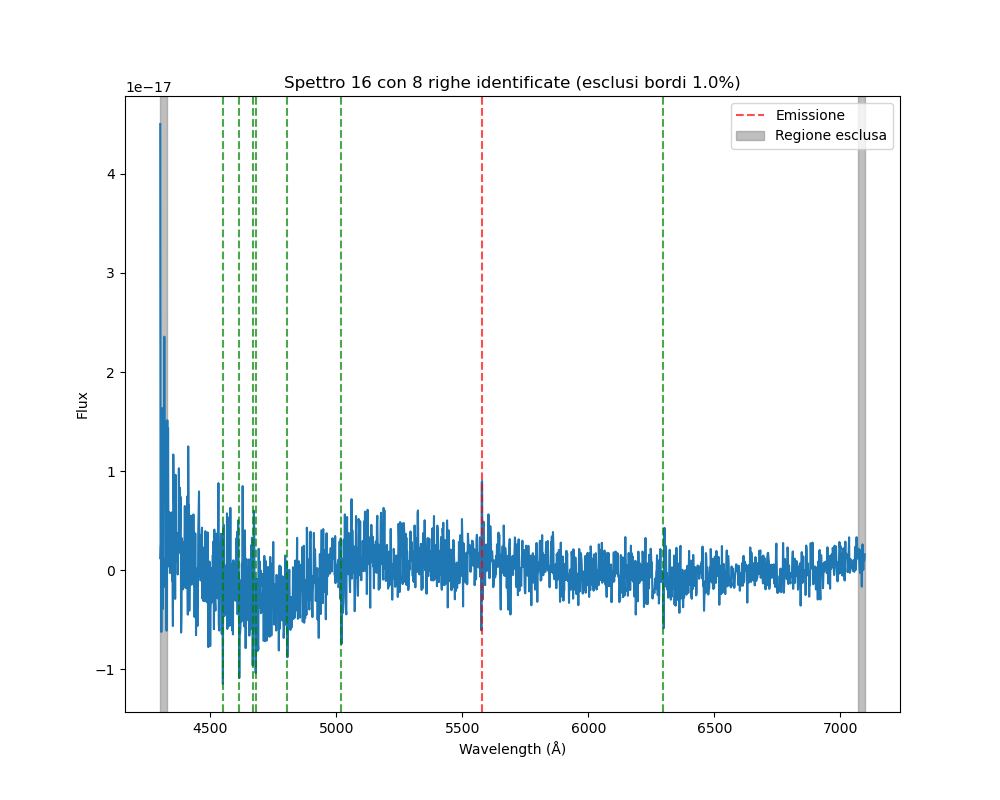

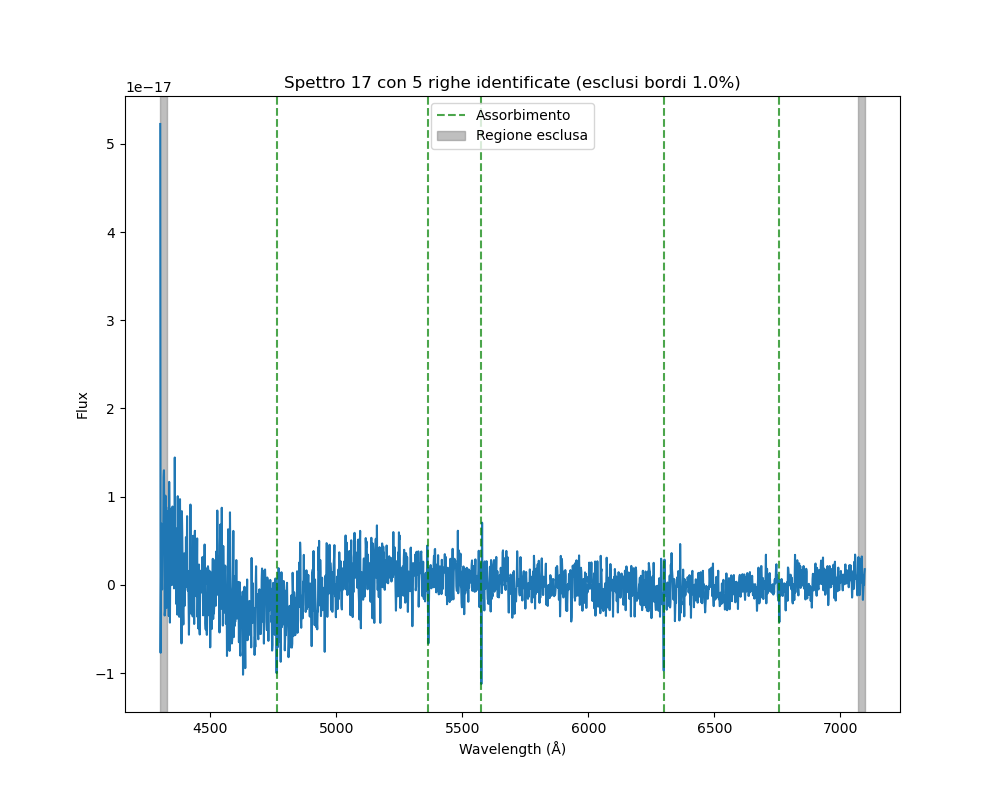

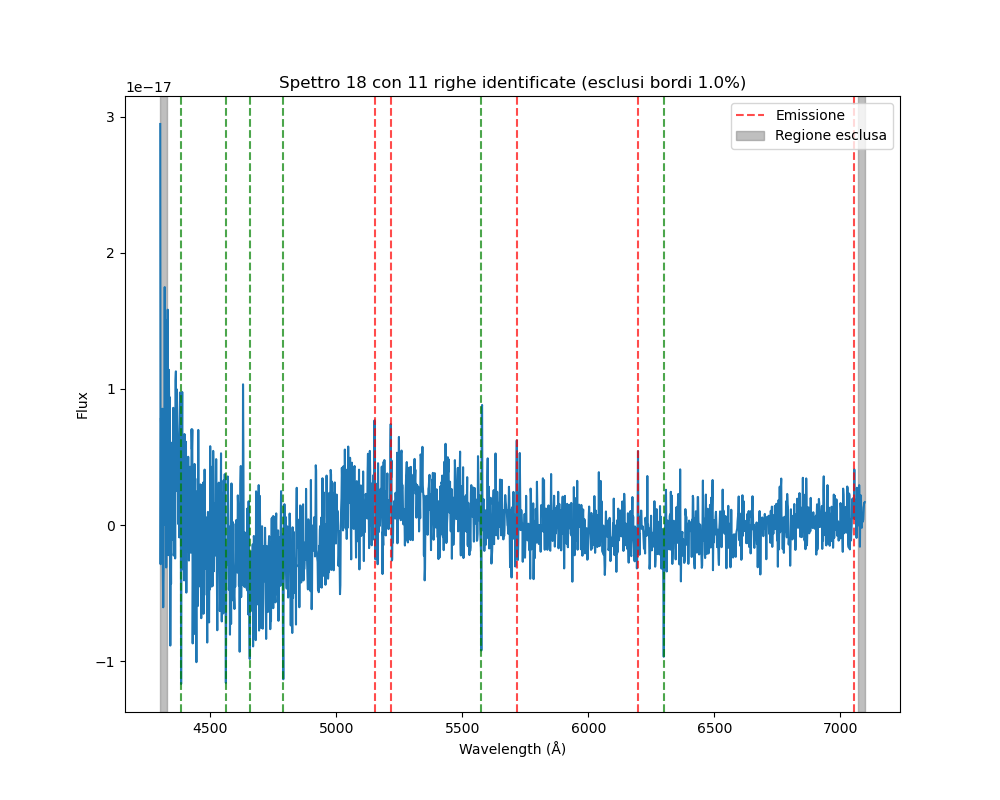

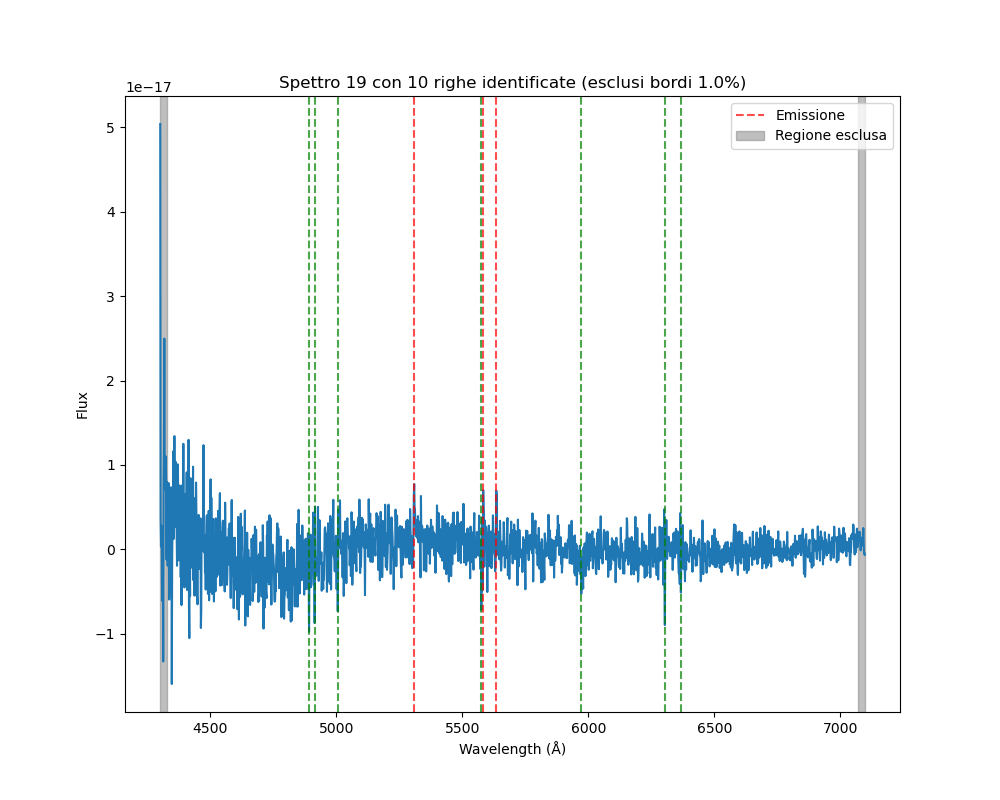

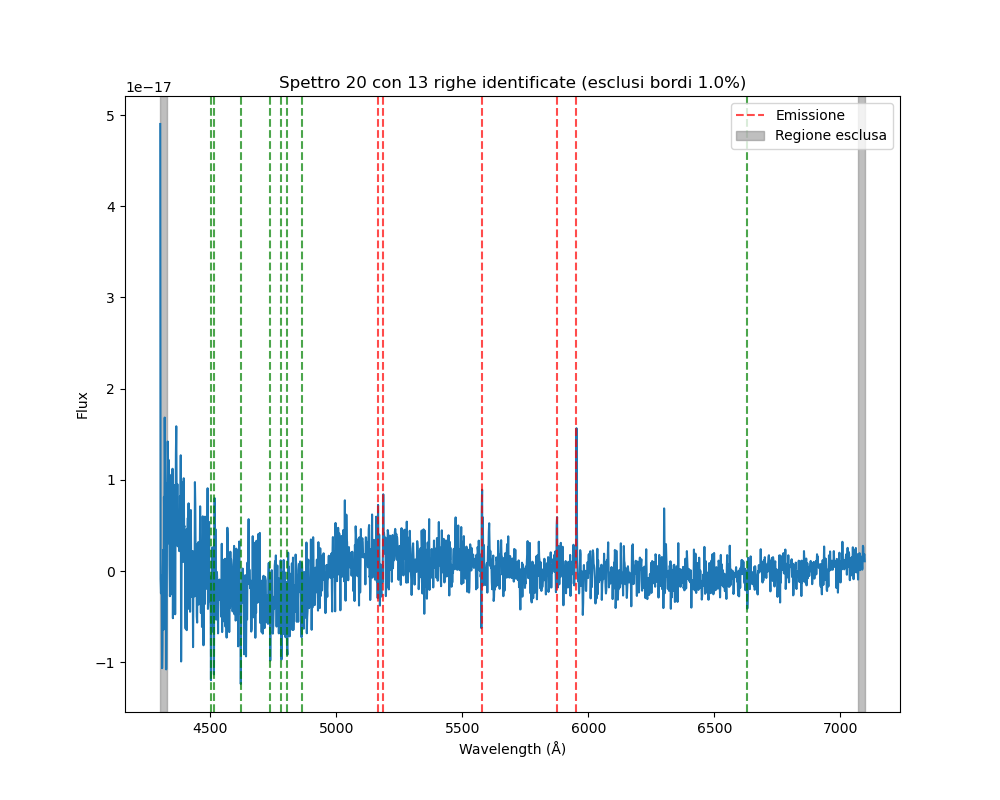

In [19]:
all_lines = []
noise_factor = [3, 3, 3, 3, 3, 6, 8, 6, 6, 4, 4, 4, 3, 3, 3, 3, 3, 3, 3, 3]

# Definisci la percentuale di spettro da escludere ai bordi (es. 5% per lato)
edge_fraction = 0.01
n_points = len(wv)
start_idx = int(n_points * edge_fraction)
end_idx = int(n_points * (1 - edge_fraction))

# Crea gli array ritagliati per la regione centrale
wv_central = wv[start_idx:end_idx]

for i in range(20):
    # Usa tutto lo spettro per il fitting del continuum
    spectrum = Spectrum(
        spectral_axis=wv * u.Angstrom,
        flux = spectra[i]* 1e-16 *u.erg / (u.cm**2 * u.s * u.Angstrom),  
        uncertainty = StdDevUncertainty(spectra_err[i]* 1e-16 *u.erg / (u.cm**2 * u.s * u.Angstrom))
    )
    g1_fit = fit_generic_continuum(spectrum, fitter=LinearLSQFitter())
    y_continuum_fitted = g1_fit(wv * u.Angstrom)
    #f, ax = plt.subplots(figsize = (10,8))
    #ax.plot(wv * u.Angstrom, spectra[i]* 1e-16*u.erg / (u.cm**2 * u.s * u.Angstrom))
    #ax.plot(wv * u.Angstrom, y_continuum_fitted)
    #ax.set_title("Continuum Fitting")
    
    flux_continuum_subtracted = spectrum.flux - y_continuum_fitted
    #f2, ax2 = plt.subplots(figsize = (10,8))
    #ax2.plot(wv * u.Angstrom, flux_continuum_subtracted)
    
    #ax2.set_title("Spectrum without continuum")
    
    # Crea lo spettro solo per la regione centrale (senza bordi)
    spectrum_no_continuum_central = Spectrum(
        spectral_axis=wv_central * u.Angstrom,
        flux=flux_continuum_subtracted[start_idx:end_idx],
        uncertainty=StdDevUncertainty(spectra_err[i][start_idx:end_idx] * 1e-16 * u.erg / (u.cm**2 * u.s * u.Angstrom))
    )
    
    # Trova le righe solo nella regione centrale
    lines = find_lines_threshold(spectrum_no_continuum_central, noise_factor = noise_factor[i])
    print(f"Numero di righe trovate (regione centrale): {len(lines)}")
    print(lines)
    
    f3, ax3 = plt.subplots(figsize=(10,8))
    ax3.plot(wv, flux_continuum_subtracted.value)
    
    if len(lines) < 50:  # Solo se non sono troppe
        for line_pos in lines['line_center']:
            # Trova l'indice corrispondente nel flux per determinare il tipo di riga
            # Trova l'indice più vicino alla posizione della riga nell'array wv_central
            line_idx = np.argmin(np.abs(wv_central - line_pos.value))
            # Ottieni l'indice corrispondente nel flux completo
            flux_idx = start_idx + line_idx
            
            # Determina se è emissione (positiva) o assorbimento (negativa)
            if flux_continuum_subtracted[flux_idx].value > 0:
                # Riga di emissione - colore rosso
                ax3.axvline(x=line_pos.value, color='red', alpha=0.7, linestyle='--', 
                           label='Emissione' if line_pos == lines['line_center'][0] else "")
            else:
                # Riga di assorbimento - colore verde
                ax3.axvline(x=line_pos.value, color='green', alpha=0.7, linestyle='--',
                           label='Assorbimento' if line_pos == lines['line_center'][0] else "")
    
    # Aggiungi linee verticali per indicare i bordi esclusi
    ax3.axvspan(wv[0], wv[start_idx], alpha=0.5, color='gray', zorder=1, label='Regione esclusa')
    ax3.axvspan(wv[end_idx-1], wv[-1], alpha=0.5, color='gray', zorder=1)
    #ax3.axvline(x=wv[start_idx], color='gray', alpha=0.5, linestyle='-', linewidth=2, label='Regione esclusa')
    #ax3.axvline(x=wv[end_idx-1], color='gray', alpha=0.5, linestyle='-', linewidth=2)
    ax3.legend()
    
    ax3.set_title(f"Spettro {i+1} con {len(lines)} righe identificate (esclusi bordi {edge_fraction*100:.1f}%)")
    ax3.set_xlabel('Wavelength (Å)')
    ax3.set_ylabel('Flux')
    all_lines.append(lines)

In [20]:
#reference wv in air
l_Hgam = 4340.5
l_HA = 6562.8
l_HB = 4861.3
l_NII_1 = 6548.1
l_NII_2 = 6583.4
l_SII_1 = 6717.0
l_SII_2 = 6731.3
l_OIII_1 = 4958.9
l_OIII_2 = 5006.8
l_He_1 = 5875.6

lines_6 = [l_HB, l_OIII_1, l_OIII_2, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_7 = [l_Hgam, l_HB, l_OIII_1, l_OIII_2, l_He_1, l_NII_1, l_HA, l_NII_2, l_SII_1, l_SII_2] #2
lines_8 = [l_Hgam, l_HB, l_OIII_1, l_OIII_2, l_NII_1, l_HA, l_NII_2, l_SII_1, l_SII_2] 
lines_9 = [l_HB, l_OIII_2, l_HA, l_NII_2,l_SII_1, l_SII_2]
lines_10 = [l_OIII_2, l_HA, l_NII_2,l_SII_1, l_SII_2]
lines_11 = [l_HA, l_NII_2, l_SII_1, l_SII_2] #anche 12
lines_13 = [l_HA, l_NII_2, l_SII_1]
lines_spectrum_6 = all_lines[5]['line_center'] 
lines_spectrum_7 = all_lines[6]['line_center']
lines_spectrum_8 = all_lines[7]['line_center']
lines_spectrum_9 = all_lines[8]['line_center']
lines_spectrum_10 = all_lines[9]['line_center']
lines_spectrum_11 = all_lines[10]['line_center'] #salta la prima 
lines_spectrum_12 = all_lines[11]['line_center']
lines_spectrum_13 = all_lines[12]['line_center']

z_11= np.zeros(len(lines_11))

def redshift(lines, lines_spectrum):
    z = np.zeros(len(lines))
    for i in range(len(lines)):
        z[i] = lines_spectrum[i].value / lines[i] - 1
    z_mean = np.mean(z)
    z_std = np.std(z)
    return z_mean, z_std
        
z_6_mean, z_6_std = redshift(lines_6, lines_spectrum_6) 
z_7_mean, z_7_std = redshift(lines_7, lines_spectrum_7) 
z_8_mean, z_8_std = redshift(lines_8, lines_spectrum_8) 
z_9_mean, z_9_std = redshift(lines_9, lines_spectrum_9) 
z_10_mean, z_10_std = redshift(lines_10, lines_spectrum_10) 
z_12_mean, z_12_std = redshift(lines_11, lines_spectrum_12) 
z_13_mean, z_13_std = redshift(lines_13, lines_spectrum_13) 


for i in range(4):
    z_11[i] = lines_spectrum_11[i+1].value / lines_11[i] - 1
z_11_mean = np.mean(z_11)
z_11_std = np.std(z_11)

#for i in range(len(lines_13)):
#    z_13[i] = lines_spectrum_13[i+1].value / lines_13[i] - 1

z = [np.nan, np.nan, np.nan, np.nan, np.nan, z_6_mean, z_7_mean, z_8_mean, z_9_mean, z_10_mean, z_11_mean, z_12_mean, z_13_mean, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan]
z_err = [np.nan, np.nan, np.nan, np.nan, np.nan, z_6_std, z_7_std, z_8_std, z_9_std, z_10_std, z_11_std, z_12_std, z_13_std, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan]

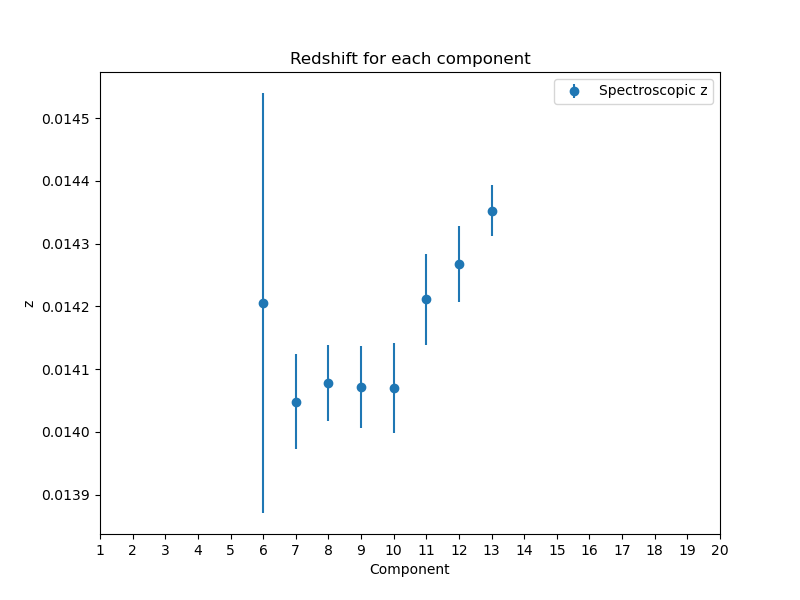

In [21]:
plt.figure(figsize=(8, 6))
comp = np.arange(1, 21, 1)
plt.errorbar(comp, z, z_err, ls='none', marker = 'o', label = 'Spectroscopic z')
plt.xlabel('Component')
plt.ylabel('z')
plt.xticks(comp)
#plt.axhline(0.01505 , color = 'red', label = 'Tabulated z')
plt.title('Redshift for each component')
plt.legend()
plt.savefig('Redshift_grad', bbox_inches='tight')

red_table = np.column_stack((z, z_err))
np.savetxt('redshift_grad.txt', red_table, header='redshift redshift_error', fmt='%.5f',delimiter='\t')

## S/N emission lines 

In [40]:
def SNR_line(wv, wv_line, spectrum): 
    left_region = (wv > wv_line-15)*(wv < wv_line-5) 
    right_region = (wv > wv_line+5)*(wv < wv_line+15) 
    clean_mask = left_region | right_region

    mask = (wv > wv_line-4)*(wv < wv_line+4)
    wv_bin = np.array(np.where(mask == True))
    flux = spectrum[mask] - np.mean(spectrum[clean_mask])
    signal = (np.trapz(flux, wv[mask]))
    noise = np.std(spectrum[clean_mask] - np.mean(spectrum[clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
    SNR = signal/noise
    return SNR, signal, noise
    
def SNR_OIII_line(wv, OIII_1, OIII_2, wv_line, spectrum):
    
    left_region = (wv > OIII_1-15)*(wv < OIII_1-5) 
    right_region = (wv > OIII_2+5)*(wv < OIII_2+15) 
    clean_mask = left_region | right_region
    
    mask = (wv > wv_line-4)*(wv < wv_line+4)
    wv_bin = np.array(np.where(mask == True))
    flux = spectra[i, mask] - np.mean(spectrum[clean_mask])
    signal = (np.trapz(flux, wv[mask]))
    noise = np.std(spectrum[clean_mask] - np.mean(spectrum[clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
    SNR = signal/noise
    return SNR, signal, noise 
    
def SNR_SII_line(wv, SII_1, SII_2, wv_line, spectrum):
    
    left_region = (wv > SII_1-15)*(wv < SII_1-5) 
    right_region = (wv > SII_2+5)*(wv < SII_2+15) 
    clean_mask = left_region | right_region
    
    mask = (wv > wv_line-4)*(wv < wv_line+4)
    wv_bin = np.array(np.where(mask == True))
    flux = spectra[i, mask] - np.mean(spectrum[clean_mask])
    signal = (np.trapz(flux, wv[mask]))
    noise = np.std(spectrum[clean_mask] - np.mean(spectrum[clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
    SNR = signal/noise
    return SNR, signal, noise 

def SNR_HA_NII(wv, NII_1, NII_2, wv_line, spectrum):
    
    left_region = (wv > NII_1-15)*(wv < NII_1-5) 
    right_region = (wv > NII_2+5)*(wv < NII_2+15) 
    clean_mask = left_region | right_region
    
    mask = (wv > wv_line-4)*(wv < wv_line+4)
    wv_bin = np.array(np.where(mask == True))
    flux = spectra[i, mask] - np.mean(spectrum[clean_mask])
    signal = (np.trapz(flux, wv[mask]))
    noise = np.std(spectrum[clean_mask] - np.mean(spectrum[clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
    SNR = signal/noise
    return SNR, signal, noise 

def save_spectral_data(snr, signal, noise, line_name, output_dir='20ext', num_spectra=20):
    
    data = np.concatenate([
        np.array(snr).reshape(-1, 1),
        np.array(signal).reshape(-1, 1),
        np.array(noise).reshape(-1, 1)
    ], axis=1)

    df = pd.DataFrame(
        data, 
        columns=['SNR', 'Signal', 'Noise'],
        index=[f'Spettro_{i+1}' for i in range(num_spectra)]
    )
    
    df_path = os.path.join(output_dir, f'SNR_{line_name}.csv')
    df.to_csv(df_path, float_format='%.3f')
    print(df)
    return df_path

In [41]:
SNR_HB = np.zeros(20)
signal_HB = np.zeros(20)
noise_HB = np.zeros(20)
SNR_SII_1 = np.zeros(20)
signal_SII_1 = np.zeros(20)
noise_SII_1 = np.zeros(20)
SNR_SII_2 = np.zeros(20)
signal_SII_2 = np.zeros(20)
noise_SII_2 = np.zeros(20)
SNR_NII_1 = np.zeros(20)
signal_NII_1 = np.zeros(20)
noise_NII_1 = np.zeros(20)
SNR_NII_2 = np.zeros(20)
signal_NII_2 = np.zeros(20)
noise_NII_2 = np.zeros(20)
SNR_HA = np.zeros(20)
signal_HA = np.zeros(20)
noise_HA = np.zeros(20)
SNR_OIII_1 = np.zeros(20)
signal_OIII_1 = np.zeros(20)
noise_OIII_1 = np.zeros(20)
SNR_OIII_2 = np.zeros(20)
signal_OIII_2 = np.zeros(20)
noise_OIII_2 = np.zeros(20)

for i in range(20):
    if np.isnan(z[i]) == False: 
        l_Hgam = 4340.5*(1+z[i])
        l_HA = 6562.8*(1+z[i])
        l_HB = 4861.3*(1+z[i])
        l_NII_1 = 6548.1*(1+z[i])
        l_NII_2 = 6583.4*(1+z[i])
        l_SII_1 = 6717.0*(1+z[i])
        l_SII_2 = 6731.3*(1+z[i])
        l_OIII_1 = 4958.9*(1+z[i])
        l_OIII_2 = 5006.8*(1+z[i])
        l_He_1 = 5875.6*(1+z[i])
        SNR_HB[i], signal_HB[i], noise_HB[i] = SNR_line(wv, l_HB, spectra[i])
        SNR_SII_1[i], signal_SII_1[i], noise_SII_1[i] = SNR_SII_line(wv, l_SII_1, l_SII_2, l_SII_1, spectra[i])
        SNR_SII_2[i], signal_SII_2[i], noise_SII_2[i] = SNR_SII_line(wv, l_SII_1, l_SII_2, l_SII_2, spectra[i])
        SNR_NII_1[i], signal_NII_1[i], noise_NII_1[i] = SNR_HA_NII(wv, l_NII_1, l_NII_2, l_NII_1, spectra[i])
        SNR_NII_2[i], signal_NII_2[i], noise_NII_2[i] = SNR_HA_NII(wv, l_NII_1, l_NII_2, l_NII_2, spectra[i])
        SNR_HA[i], signal_HA[i], noise_HA[i] = SNR_HA_NII(wv, l_NII_1, l_NII_2, l_HA, spectra[i])
        SNR_OIII_1[i], signal_OIII_1[i], noise_OIII_1[i] = SNR_OIII_line(wv, l_OIII_1, l_OIII_2, l_OIII_1, spectra[i])
        SNR_OIII_2[i], signal_OIII_2[i], noise_OIII_2[i] = SNR_OIII_line(wv, l_OIII_1, l_OIII_2, l_OIII_2, spectra[i])
    else:
        SNR_HB[i] = np.nan
        signal_HB[i] = np.nan
        noise_HB[i] = np.nan
        SNR_SII_1[i] = np.nan 
        signal_SII_1[i] = np.nan 
        noise_SII_1[i] = np.nan 
        SNR_SII_2[i] = np.nan 
        signal_SII_2[i] = np.nan 
        noise_SII_2[i] = np.nan 
        SNR_NII_1[i] = np.nan 
        signal_NII_1[i] = np.nan 
        noise_NII_1[i] = np.nan 
        SNR_NII_2[i] = np.nan 
        signal_NII_2[i] = np.nan 
        noise_NII_2[i] = np.nan 
        SNR_HA[i] = np.nan 
        signal_HA[i] = np.nan 
        noise_HA[i] = np.nan 
        SNR_OIII_1[i] = np.nan 
        signal_OIII_1[i] = np.nan 
        noise_OIII_1[i] = np.nan 
        SNR_OIII_2[i] = np.nan 
        signal_OIII_2[i] = np.nan
        noise_OIII_2[i] = np.nan
        
save_spectral_data(SNR_HB, signal_HB, noise_HB, 'HB')
save_spectral_data(SNR_SII_1, signal_SII_1, noise_SII_1, 'SII_1')
save_spectral_data(SNR_SII_2, signal_SII_2, noise_SII_2, 'SII_2')
save_spectral_data(SNR_NII_1, signal_NII_1, noise_NII_1, 'NII_1')
save_spectral_data(SNR_NII_2, signal_NII_2, noise_NII_2, 'NII_2')
save_spectral_data(SNR_HA, signal_HA, noise_HA, 'HA')
save_spectral_data(SNR_OIII_1, signal_OIII_1, noise_OIII_1, 'OIII_1')
save_spectral_data(SNR_OIII_2, signal_OIII_2, noise_OIII_2, 'OIII_2')

                  SNR    Signal     Noise
Spettro_1         NaN       NaN       NaN
Spettro_2         NaN       NaN       NaN
Spettro_3         NaN       NaN       NaN
Spettro_4         NaN       NaN       NaN
Spettro_5         NaN       NaN       NaN
Spettro_6   18.563641  1.481935  0.079830
Spettro_7   42.940035  5.914049  0.137728
Spettro_8   28.499323  3.103030  0.108881
Spettro_9    7.789688  0.573576  0.073633
Spettro_10   0.930175  0.097224  0.104522
Spettro_11  -1.347375 -0.128771  0.095572
Spettro_12  -1.424098 -0.120686  0.084745
Spettro_13   0.842835  0.070696  0.083878
Spettro_14        NaN       NaN       NaN
Spettro_15        NaN       NaN       NaN
Spettro_16        NaN       NaN       NaN
Spettro_17        NaN       NaN       NaN
Spettro_18        NaN       NaN       NaN
Spettro_19        NaN       NaN       NaN
Spettro_20        NaN       NaN       NaN
                  SNR    Signal     Noise
Spettro_1         NaN       NaN       NaN
Spettro_2         NaN       NaN   

'20ext\\SNR_OIII_2.csv'

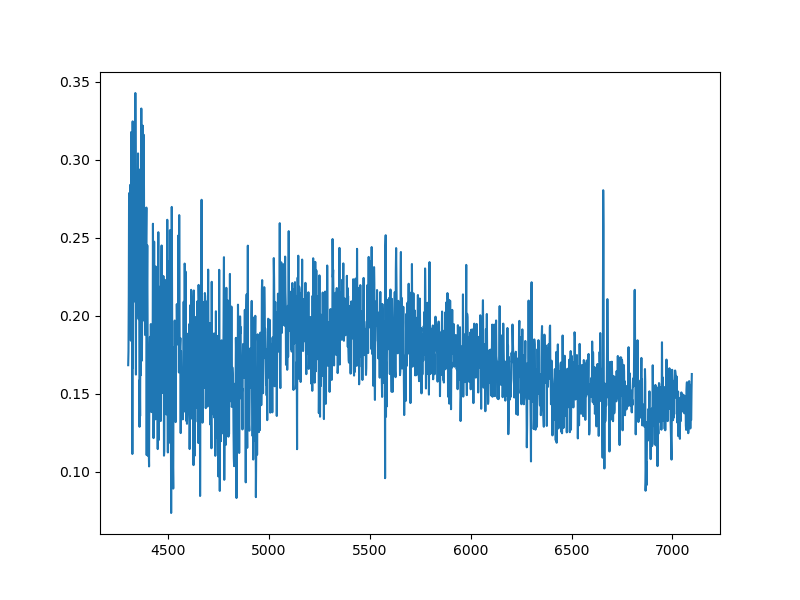

In [48]:
plt.figure(figsize = (8, 6))
plt.plot(wv, spectra[12])

In [47]:
l_OIII_2

5078.661538806257